# PCA Subspace Stability Analysis

**Motivation:** How much is the **across-family similarity** of individual subject RDMs driven by the embedding spaces (CLIP or DINOv3), despite feeding different input images? Are models capturing nuances in the visual input, or converging those inputs?

We compare **individual subject RDMs** (one RDM per subject, aggregated across age like notebook 06), not developmental trajectory (younger vs older).

**Idea:** Restrict to the subspace spanned by the **observed object crops** (age-month level embeddings). We:
1. Stack all observed embeddings and fit PCA.
2. Project all embeddings onto this PCA subspace (e.g. 95% variance).
3. Build one RDM per subject in full space and in PCA subspace (aggregate across age_mo per subject–category).
4. Compute **across-subject similarity**: mean pairwise Spearman correlation between subject RDMs (using only overlapping categories per pair).

**Interpretation:** If mean pairwise correlation **drops** in the PCA subspace → the full embedding space may be adding shared structure across subjects beyond the observed inputs. If it **remains similar** → the observed input diversity suffices to explain across-family similarity.

## What are the subspaces?

**1. Full embedding space**  
The raw output space of the model (e.g. **512 dimensions** for CLIP ViT, **768** for DINOv2 ViT-B). Every object-crop embedding is a point in this space. Stability in the “original” analysis is computed using these full-dimensional vectors (after the usual normalization from notebook 05).

**2. PCA subspace (observed subspace)**  
A **lower-dimensional linear subspace** of the full embedding space, defined by the data you actually have:

- We take **all** age-month level embeddings (one vector per subject × age_mo × category): these are the “observed object crops” in embedding form.
- We stack them into a matrix and fit **PCA** on that matrix.
- We keep enough components to explain a chosen fraction of variance (e.g. **95%**), giving e.g. ~200–250 components instead of 512.
- The **PCA subspace** is the span of those components: the set of all linear combinations of those principal axes. Geometrically, it’s the hyperplane (in the full 512-d space) that best fits the cloud of observed embeddings.

So:
- **Full space** = all 512 (or 768) dimensions the model uses.
- **PCA subspace** = the directions in which your observed embeddings actually vary (up to 95% of their variance). Dimensions that your data hardly use are effectively dropped when we project onto this subspace.

When we “recalculate stability in the PCA subspace,” we **project** every embedding onto that hyperplane (using the PCA loadings), then compute individual subject RDMs and across-subject pairwise RDM correlations in that projected space only.

## How we calculate RDM correlation

**Within-subject (not across families)**  
For each subject we compute **one** stability value: the correlation between that subject’s **younger** RDM and **older** RDM. We do not correlate RDMs across different subjects/families.

**Same category order everywhere**  
- All RDMs use a single **ordered category list** (163 categories, from the predefined `category_order_reorganized.txt` used in notebook 07).  
- So for every subject and every bin (younger/older), row and column index `i` always refers to the same category. The two RDMs we correlate (younger vs older) are therefore in the **same order**.

**Only overlapping categories used**  
- Younger and older bins can have different sets of categories (e.g. younger has 150, older has 155).  
- We take **common categories** = categories that appear in **both** the younger and older bin for that subject, **in the predefined order**.  
- We extract the submatrices for those common categories only (same indices in both RDMs), take the **upper triangle** (excluding diagonal) of each submatrix, and compute **Spearman correlation** between the two sets of distances.  
- So we only compare distances for **identical category pairs** that exist in both bins; no cross-family category mismatch.

## Setup and paths

In [17]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paths (match notebook 07)
embeddings_base = Path("/data2/dataset/babyview/868_hours/outputs/yoloe_cdi_embeddings")
# embedding_type = "clip"  # or "dinov3"
embedding_type = "dinov3"  # or "dinov3"
if embedding_type == "clip":
    normalized_embeddings_dir = embeddings_base / "clip_embeddings_grouped_by_age-mo_normalized"
else:
    normalized_embeddings_dir = embeddings_base / "facebook_dinov3-vitb16-pretrain-lvd1689m_grouped_by_age-mo_normalized"

# Run notebook from analysis/individual_analyses so relative paths work
script_dir = Path(".").resolve()
categories_file = script_dir / "../../data/things_bv_overlap_categories_exclude_zero_precisions.txt"
category_order_file = script_dir / "../vss-2026/bv_things_comp_12252025/bv_clip_filtered_zscored_hierarchical_163cats/category_order_reorganized.txt"

output_dir = script_dir / f"individual_subject_rdms_{embedding_type}_pca_subspace"

print(f"Embedding: {embedding_type}")
print(f"Embeddings: {normalized_embeddings_dir}")
print(f"Output: {output_dir}")

Embedding: dinov3
Embeddings: /data2/dataset/babyview/868_hours/outputs/yoloe_cdi_embeddings/facebook_dinov3-vitb16-pretrain-lvd1689m_grouped_by_age-mo_normalized
Output: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/individual_subject_rdms_dinov3_pca_subspace


## Run PCA subspace stability

In [18]:
from pca_subspace_stability import run_pca_stability

summary_df = run_pca_stability(
    embeddings_dir=normalized_embeddings_dir,
    categories_file=categories_file,
    category_order_file=category_order_file,
    output_dir=output_dir,
    excluded_subject="00270001",
    min_categories_per_age_bin=8,
    n_components=0.95,  # keep components explaining 95% variance
)
summary_df

Loading embeddings...


Loading categories: 100%|██████████| 163/163 [00:01<00:00, 136.42it/s]


Using 163 categories in fixed order (saved to ordered_categories.txt)
Stacked shape: (34550, 768) (n_observations, n_dims)
PCA: n_components=466, explained variance ratio (sum)=0.9502
Saved /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/individual_subject_rdms_dinov3_pca_subspace/across_subject_rdm_similarity_summary.csv
  Full space: mean pairwise RDM correlation = 0.6817 (n_subjects=31, n_pairs=465)
  PCA subspace: mean pairwise RDM correlation = 0.6809 (n_subjects=31, n_pairs=465)


,space,mean_pairwise_rdm_correlation,n_subjects,n_pairs
0,full,0.681749,31,465
1,pca_subspace,0.680895,31,465


## Optional: Run for DINOv3 as well

Run the same PCA subspace stability pipeline for DINOv3 embeddings. Results are written to `individual_subject_rdms_dinov3_pca_subspace/`. The rest of the notebook (load/plots) continues to use the embedding type set in **Setup** (e.g. CLIP). To view DINOv3 plots, set `embedding_type = "dinov3"` in Setup and re-run from the top, or run the comparison cell below.

In [19]:
# Run PCA subspace stability for DINOv3 (writes to its own output dir)
from pca_subspace_stability import run_pca_stability

output_dir_dinov3 = script_dir / "individual_subject_rdms_dinov3_pca_subspace"
normalized_embeddings_dinov3 = embeddings_base / "facebook_dinov3-vitb16-pretrain-lvd1689m_grouped_by_age-mo_normalized"
if normalized_embeddings_dinov3.exists():
    _ = run_pca_stability(
        embeddings_dir=normalized_embeddings_dinov3,
        categories_file=categories_file,
        category_order_file=category_order_file,
        output_dir=output_dir_dinov3,
        excluded_subject="00270001",
        min_categories_per_age_bin=8,
        n_components=0.95,
    )
    print(f"DINOv3 results saved to {output_dir_dinov3}")
else:
    print(f"DINOv3 embeddings dir not found: {normalized_embeddings_dinov3}")

Loading embeddings...


Loading categories: 100%|██████████| 163/163 [00:01<00:00, 136.40it/s]


Using 163 categories in fixed order (saved to ordered_categories.txt)
Stacked shape: (34550, 768) (n_observations, n_dims)
PCA: n_components=466, explained variance ratio (sum)=0.9502
Saved /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/individual_subject_rdms_dinov3_pca_subspace/across_subject_rdm_similarity_summary.csv
  Full space: mean pairwise RDM correlation = 0.6817 (n_subjects=31, n_pairs=465)
  PCA subspace: mean pairwise RDM correlation = 0.6809 (n_subjects=31, n_pairs=465)
DINOv3 results saved to /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/individual_subject_rdms_dinov3_pca_subspace


## Load across-subject similarity results

In [20]:
summary_path = output_dir / "across_subject_rdm_similarity_summary.csv"
pair_full_path = output_dir / "pairwise_rdm_correlations_full.csv"
pair_pca_path = output_dir / "pairwise_rdm_correlations_pca_subspace.csv"

if summary_path.exists():
    summary = pd.read_csv(summary_path)
    print(summary.to_string())
    pair_full = pd.read_csv(pair_full_path) if pair_full_path.exists() else None
    pair_pca = pd.read_csv(pair_pca_path) if pair_pca_path.exists() else None
else:
    summary = pair_full = pair_pca = None
    print("Run the PCA subspace stability cell first.")

          space  mean_pairwise_rdm_correlation  n_subjects  n_pairs
0          full                       0.681749          31      465
1  pca_subspace                       0.680895          31      465


## Optional: Compare CLIP vs DINOv3

If you have run the pipeline for both CLIP and DINOv3, load both summaries and print a side-by-side comparison.

In [21]:
# Load and compare CLIP vs DINOv3 (when both have been run)
dir_clip = script_dir / "individual_subject_rdms_clip_pca_subspace"
dir_dinov3 = script_dir / "individual_subject_rdms_dinov3_pca_subspace"
path_clip = dir_clip / "across_subject_rdm_similarity_summary.csv"
path_dinov3 = dir_dinov3 / "across_subject_rdm_similarity_summary.csv"
if path_clip.exists():
    clip_df = pd.read_csv(path_clip)
    clip_df["embedding"] = "CLIP"
    print("--- CLIP ---")
    print(clip_df.to_string(index=False))
if path_dinov3.exists():
    dinov3_df = pd.read_csv(path_dinov3)
    dinov3_df["embedding"] = "DINOv3"
    print("\n--- DINOv3 ---")
    print(dinov3_df.to_string(index=False))
if path_clip.exists() and path_dinov3.exists():
    both = pd.concat([clip_df, dinov3_df], ignore_index=True)
    print("\nSide-by-side:")
    print(both[["embedding", "space", "mean_pairwise_rdm_correlation", "n_subjects", "n_pairs"]].to_string(index=False))

--- CLIP ---
       space  mean_pairwise_rdm_correlation  n_subjects  n_pairs embedding
        full                       0.660599          31      465      CLIP
pca_subspace                       0.659774          31      465      CLIP

--- DINOv3 ---
       space  mean_pairwise_rdm_correlation  n_subjects  n_pairs embedding
        full                       0.681749          31      465    DINOv3
pca_subspace                       0.680895          31      465    DINOv3

Side-by-side:
embedding        space  mean_pairwise_rdm_correlation  n_subjects  n_pairs
     CLIP         full                       0.660599          31      465
     CLIP pca_subspace                       0.659774          31      465
   DINOv3         full                       0.681749          31      465
   DINOv3 pca_subspace                       0.680895          31      465


## Plot: stability in full space vs PCA subspace

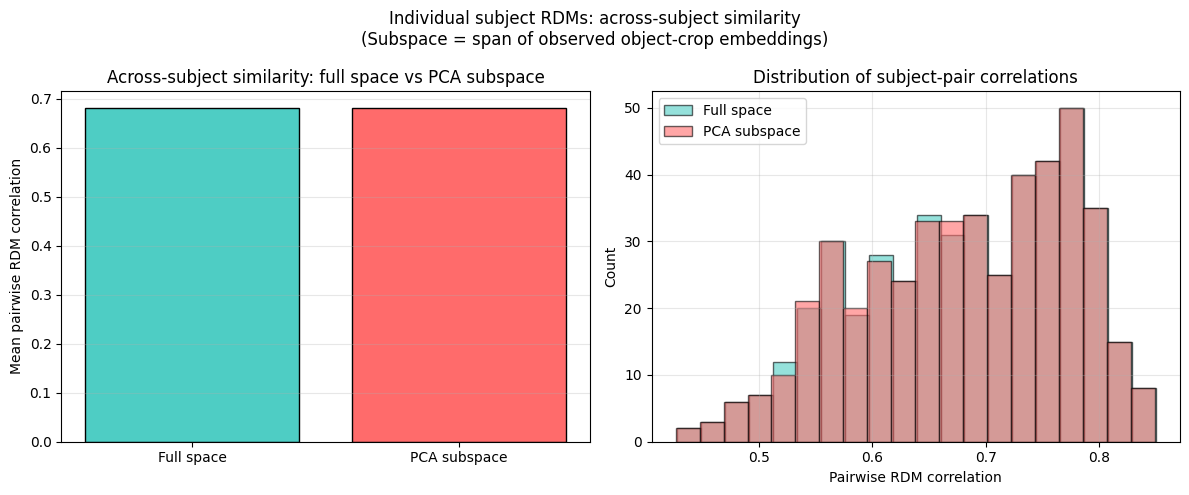

Saved /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/individual_subject_rdms_dinov3_pca_subspace/across_subject_similarity_full_vs_pca_subspace.png


In [22]:
if summary is not None and len(summary) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Bar: mean pairwise RDM correlation (full vs PCA subspace)
    ax = axes[0]
    ax.bar([0, 1], summary["mean_pairwise_rdm_correlation"], color=["#4ECDC4", "#FF6B6B"], edgecolor="k")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Full space", "PCA subspace"])
    ax.set_ylabel("Mean pairwise RDM correlation")
    ax.set_title("Across-subject similarity: full space vs PCA subspace")
    ax.grid(True, alpha=0.3, axis="y")

    # Histograms of pairwise correlations (if available)
    ax = axes[1]
    if pair_full is not None and pair_pca is not None:
        ax.hist(pair_full["correlation"], bins=20, alpha=0.6, label="Full space", color="#4ECDC4", edgecolor="black")
        ax.hist(pair_pca["correlation"], bins=20, alpha=0.6, label="PCA subspace", color="#FF6B6B", edgecolor="black")
        ax.set_xlabel("Pairwise RDM correlation")
        ax.set_ylabel("Count")
        ax.set_title("Distribution of subject-pair correlations")
        ax.legend()
    else:
        ax.text(0.5, 0.5, "Pairwise CSVs not found", ha="center", va="center", transform=ax.transAxes)
    ax.grid(True, alpha=0.3)

    plt.suptitle("Individual subject RDMs: across-subject similarity\n(Subspace = span of observed object-crop embeddings)", fontsize=12)
    plt.tight_layout()
    out_path = output_dir / "across_subject_similarity_full_vs_pca_subspace.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {out_path}")
else:
    print("Run the PCA subspace stability cell first.")

## Additional visualizations

Scatter of pairwise correlations (full vs PCA subspace), subject×subject correlation matrices, and correlation vs number of overlapping categories.

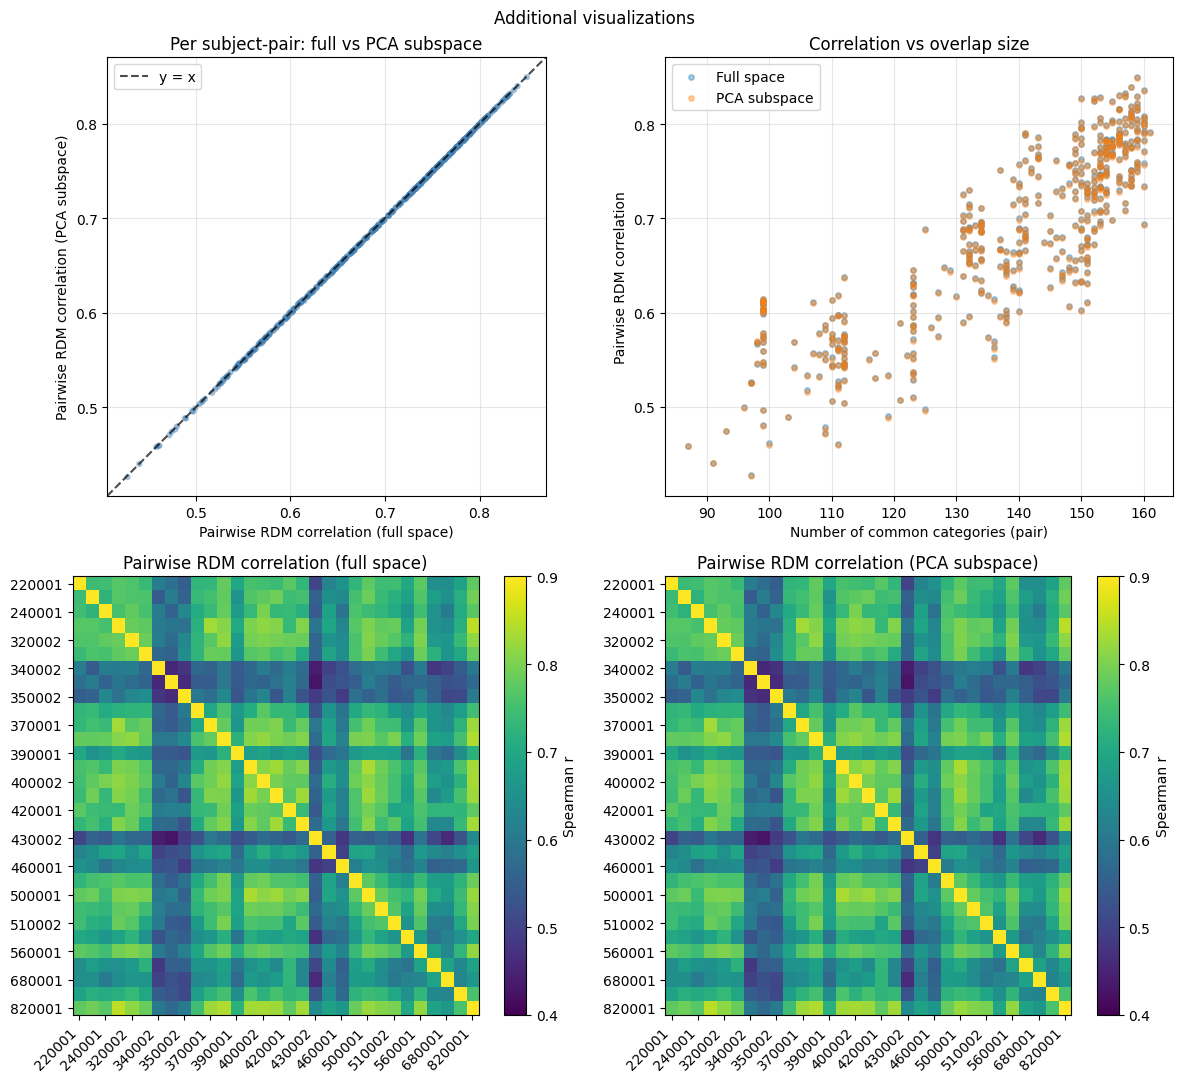

Saved /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/individual_subject_rdms_dinov3_pca_subspace/additional_visualizations.png


In [23]:
# Additional plots (requires summary + pair_full + pair_pca from above)
if pair_full is not None and pair_pca is not None:
    # Merge so each row is one subject-pair with corr_full and corr_pca
    merge_keys = ["subject_id_1", "subject_id_2"]
    merged = pair_full[merge_keys + ["correlation", "n_common_categories"]].rename(
        columns={"correlation": "corr_full"}
    ).merge(
        pair_pca[merge_keys + ["correlation"]].rename(columns={"correlation": "corr_pca"}),
        on=merge_keys,
        how="inner",
    )

    fig, axes = plt.subplots(2, 2, figsize=(12, 11))

    # 1. Scatter: full vs PCA subspace (per subject-pair)
    ax = axes[0, 0]
    ax.scatter(merged["corr_full"], merged["corr_pca"], alpha=0.5, s=20, c="steelblue", edgecolors="none")
    lims = [merged[["corr_full", "corr_pca"]].min().min() - 0.02, merged[["corr_full", "corr_pca"]].max().max() + 0.02]
    ax.plot(lims, lims, "k--", alpha=0.7, label="y = x")
    ax.set_xlabel("Pairwise RDM correlation (full space)")
    ax.set_ylabel("Pairwise RDM correlation (PCA subspace)")
    ax.set_title("Per subject-pair: full vs PCA subspace")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2. Correlation vs n_common_categories (full space; PCA similar)
    ax = axes[0, 1]
    ax.scatter(merged["n_common_categories"], merged["corr_full"], alpha=0.4, s=15, c="C0", label="Full space")
    ax.scatter(merged["n_common_categories"], merged["corr_pca"], alpha=0.4, s=15, c="C1", label="PCA subspace")
    ax.set_xlabel("Number of common categories (pair)")
    ax.set_ylabel("Pairwise RDM correlation")
    ax.set_title("Correlation vs overlap size")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 3. Subject x subject correlation matrix (full space)
    ax = axes[1, 0]
    subjects = sorted(set(pair_full["subject_id_1"]) | set(pair_full["subject_id_2"]))
    n_subj = len(subjects)
    idx = {s: i for i, s in enumerate(subjects)}
    mat_full = np.nan * np.ones((n_subj, n_subj))
    for _, row in pair_full.iterrows():
        i, j = idx[row["subject_id_1"]], idx[row["subject_id_2"]]
        mat_full[i, j] = mat_full[j, i] = row["correlation"]
    np.fill_diagonal(mat_full, 1.0)
    im = ax.imshow(mat_full, aspect="auto", cmap="viridis", vmin=0.4, vmax=0.9)
    ax.set_title("Pairwise RDM correlation (full space)")
    ax.set_xticks(np.arange(0, n_subj, max(1, n_subj // 15)))
    ax.set_xticklabels([subjects[i] for i in range(0, n_subj, max(1, n_subj // 15))], rotation=45, ha="right")
    ax.set_yticks(np.arange(0, n_subj, max(1, n_subj // 15)))
    ax.set_yticklabels([subjects[i] for i in range(0, n_subj, max(1, n_subj // 15))])
    plt.colorbar(im, ax=ax, label="Spearman r")

    # 4. Subject x subject correlation matrix (PCA subspace)
    ax = axes[1, 1]
    mat_pca = np.nan * np.ones((n_subj, n_subj))
    for _, row in pair_pca.iterrows():
        i, j = idx[row["subject_id_1"]], idx[row["subject_id_2"]]
        mat_pca[i, j] = mat_pca[j, i] = row["correlation"]
    np.fill_diagonal(mat_pca, 1.0)
    im = ax.imshow(mat_pca, aspect="auto", cmap="viridis", vmin=0.4, vmax=0.9)
    ax.set_title("Pairwise RDM correlation (PCA subspace)")
    ax.set_xticks(np.arange(0, n_subj, max(1, n_subj // 15)))
    ax.set_xticklabels([subjects[i] for i in range(0, n_subj, max(1, n_subj // 15))], rotation=45, ha="right")
    ax.set_yticks(np.arange(0, n_subj, max(1, n_subj // 15)))
    ax.set_yticklabels([subjects[i] for i in range(0, n_subj, max(1, n_subj // 15))])
    plt.colorbar(im, ax=ax, label="Spearman r")

    plt.suptitle("Additional visualizations", fontsize=12)
    plt.tight_layout()
    out_path = output_dir / "additional_visualizations.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {out_path}")
else:
    print("Load the summary and pairwise CSVs above first.")

## Pairwise correlation for top 8 densest subjects

We restrict to the **top 8 densest subjects** (by total category count: `n_categories_younger + n_categories_older` from the trajectory file) and compare mean pairwise RDM correlation (full vs PCA subspace) for this subset, plus the 8×8 subject–subject correlation matrices.

Top 8 densest subjects (by n_categories_younger + n_categories_older): [400001, 370002, 320001, 500001, 400002, 510002, 430001, 560001]
  n_pairs (top 8): 28
  Mean pairwise RDM correlation (top 8) — Full space: 0.7921
  Mean pairwise RDM correlation (top 8) — PCA subspace: 0.7913
  (All subjects — Full: 0.6817, PCA: 0.6809)


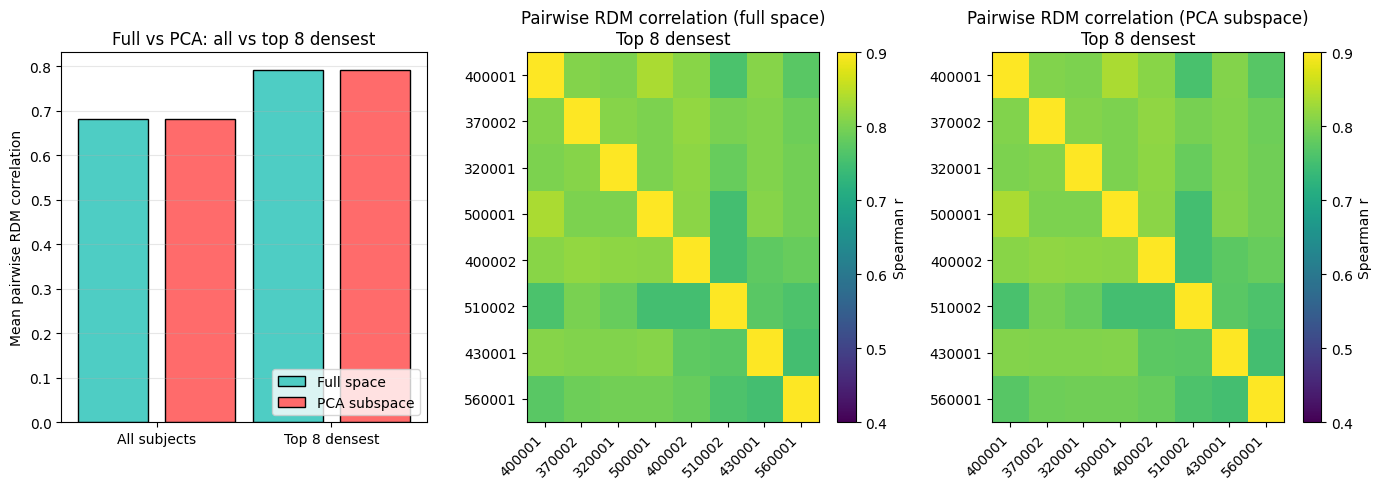

Saved /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/individual_subject_rdms_dinov3_pca_subspace/pairwise_correlation_top8_densest.png


In [24]:
# Top 8 densest subjects: pairwise correlation comparison
traj_path = output_dir / "trajectory_correlations_pca_subspace.csv"
if traj_path.exists() and pair_full is not None and pair_pca is not None:
    traj = pd.read_csv(traj_path)
    # Density = total categories (younger + older); one row per subject
    traj["density"] = traj["n_categories_younger"] + traj["n_categories_older"]
    top8 = traj.nlargest(8, "density")["subject_id"].tolist()
    top8_set = set(top8)

    # Restrict pairwise tables to pairs where both subjects are in top 8
    pair_full_top8 = pair_full[
        pair_full["subject_id_1"].isin(top8_set) & pair_full["subject_id_2"].isin(top8_set)
    ]
    pair_pca_top8 = pair_pca[
        pair_pca["subject_id_1"].isin(top8_set) & pair_pca["subject_id_2"].isin(top8_set)
    ]

    mean_full_top8 = pair_full_top8["correlation"].mean()
    mean_pca_top8 = pair_pca_top8["correlation"].mean()
    n_pairs_top8 = len(pair_full_top8)

    print("Top 8 densest subjects (by n_categories_younger + n_categories_older):", top8)
    print(f"  n_pairs (top 8): {n_pairs_top8}")
    print(f"  Mean pairwise RDM correlation (top 8) — Full space: {mean_full_top8:.4f}")
    print(f"  Mean pairwise RDM correlation (top 8) — PCA subspace: {mean_pca_top8:.4f}")
    if summary is not None and len(summary) > 0:
        mean_full_all = summary.loc[summary["space"] == "full", "mean_pairwise_rdm_correlation"].item()
        mean_pca_all = summary.loc[summary["space"] == "pca_subspace", "mean_pairwise_rdm_correlation"].item()
        print(f"  (All subjects — Full: {mean_full_all:.4f}, PCA: {mean_pca_all:.4f})")
    else:
        mean_full_all = pair_full["correlation"].mean()
        mean_pca_all = pair_pca["correlation"].mean()

    # Plot: bar chart (all vs top 8) and 8×8 matrices
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    # 1. Bar: all subjects vs top 8 (full and PCA)
    ax = axes[0]
    x = [0, 1, 2, 3]
    means = [mean_full_all, mean_pca_all, mean_full_top8, mean_pca_top8]
    colors = ["#4ECDC4", "#FF6B6B", "#4ECDC4", "#FF6B6B"]
    ax.bar(x, means, color=colors, edgecolor="k")
    ax.set_xticks([0.5, 2.5])
    ax.set_xticklabels(["All subjects", "Top 8 densest"])
    ax.set_ylabel("Mean pairwise RDM correlation")
    ax.set_title("Full vs PCA: all vs top 8 densest")
    ax.legend(
        [plt.Rectangle((0, 0), 1, 1, fc="#4ECDC4", edgecolor="k"), plt.Rectangle((0, 0), 1, 1, fc="#FF6B6B", edgecolor="k")],
        ["Full space", "PCA subspace"],
        loc="lower right",
    )
    ax.grid(True, alpha=0.3, axis="y")

    # 2. 8×8 correlation matrix — full space
    ax = axes[1]
    idx8 = {s: i for i, s in enumerate(top8)}
    mat_full_8 = np.nan * np.ones((8, 8))
    for _, row in pair_full_top8.iterrows():
        i, j = idx8[row["subject_id_1"]], idx8[row["subject_id_2"]]
        mat_full_8[i, j] = mat_full_8[j, i] = row["correlation"]
    np.fill_diagonal(mat_full_8, 1.0)
    im = ax.imshow(mat_full_8, aspect="auto", cmap="viridis", vmin=0.4, vmax=0.9)
    ax.set_xticks(np.arange(8))
    ax.set_xticklabels(top8, rotation=45, ha="right")
    ax.set_yticks(np.arange(8))
    ax.set_yticklabels(top8)
    ax.set_title("Pairwise RDM correlation (full space)\nTop 8 densest")
    plt.colorbar(im, ax=ax, label="Spearman r")

    # 3. 8×8 correlation matrix — PCA subspace
    ax = axes[2]
    mat_pca_8 = np.nan * np.ones((8, 8))
    for _, row in pair_pca_top8.iterrows():
        i, j = idx8[row["subject_id_1"]], idx8[row["subject_id_2"]]
        mat_pca_8[i, j] = mat_pca_8[j, i] = row["correlation"]
    np.fill_diagonal(mat_pca_8, 1.0)
    im = ax.imshow(mat_pca_8, aspect="auto", cmap="viridis", vmin=0.4, vmax=0.9)
    ax.set_xticks(np.arange(8))
    ax.set_xticklabels(top8, rotation=45, ha="right")
    ax.set_yticks(np.arange(8))
    ax.set_yticklabels(top8)
    ax.set_title("Pairwise RDM correlation (PCA subspace)\nTop 8 densest")
    plt.colorbar(im, ax=ax, label="Spearman r")

    plt.tight_layout()
    out_path = output_dir / "pairwise_correlation_top8_densest.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {out_path}")
else:
    print("Need trajectory_correlations_pca_subspace.csv and pairwise CSVs. Run PCA stability and load cells above.")

## Interpretations

**What we did:** We restricted the embedding space to the subspace spanned by the *observed* object-crop embeddings (PCA on all age-month level embeddings, then projected into that subspace) and recomputed developmental stability (younger vs older RDM correlation) in this reduced space.

**What to look at:**

1. **Scatter plot (original vs PCA subspace)**  
   - Points near the **y=x line** → stability is similar in full space and in the observed subspace; the pattern is explained by the diversity of inputs we actually have.  
   - Points **below** y=x → stability is *lower* in the PCA subspace for that subject; some stability in the full space may come from dimensions that go beyond the observed inputs (embedding space adding structure).

2. **Mean stability**  
   - **Mean(original) ≈ Mean(PCA subspace)** (e.g. both ~0.75) → Across subjects, developmental stability is largely captured by the subspace of observed inputs; we are not relying on extra dimensions of the embedding model.  
   - **Mean(original) > Mean(PCA subspace)** → On average, the full embedding space is contributing stability beyond what the observed inputs span (could support “embedding space driving stability”).

3. **Difference histogram**  
   - **Centered near 0** → Restricting to the observed subspace barely changes stability.  
   - **Shifted negative** → Stability tends to drop in the PCA subspace; the full space is doing some of the work.

**Bottom line for Clíona’s question:**  
- **Similar stability in both spaces** → The models appear to be reflecting nuances in the visual input; the stability we see is consistent with the diversity of the observed crops.  
- **Stability drops in the PCA subspace** → Some of the across-family stability may be coming from the embedding space (e.g. CLIP/DINO) imposing structure that goes beyond the observed inputs.

## Optional: PCA variance explained

Number of components (95% var): 466
   component  explained_variance_ratio  cumulative
0          1                  0.081538    0.081538
1          2                  0.039627    0.121164
2          3                  0.031854    0.153018
3          4                  0.020576    0.173594
4          5                  0.020159    0.193752
5          6                  0.018624    0.212376
6          7                  0.017553    0.229929
7          8                  0.017035    0.246964
8          9                  0.014469    0.261433
9         10                  0.013764    0.275198


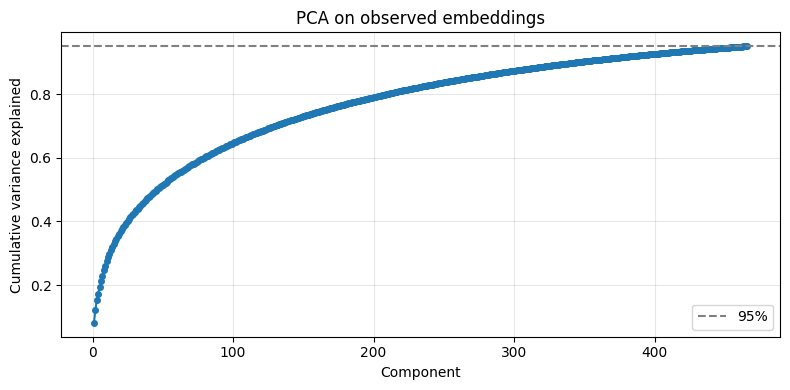

In [25]:
pca_var_path = output_dir / "pca_variance.csv"
if pca_var_path.exists():
    pca_var = pd.read_csv(pca_var_path)
    print(f"Number of components (95% var): {len(pca_var)}")
    print(pca_var.head(10).to_string())
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(pca_var["component"], pca_var["cumulative"], "o-", markersize=4)
    ax.axhline(0.95, color="gray", linestyle="--", label="95%")
    ax.set_xlabel("Component")
    ax.set_ylabel("Cumulative variance explained")
    ax.set_title("PCA on observed embeddings")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Run the PCA stability cell first.")